<a href="https://colab.research.google.com/github/mariapeguerosolv-cmd/Predictive-collection-Act-4/blob/main/Actividad_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

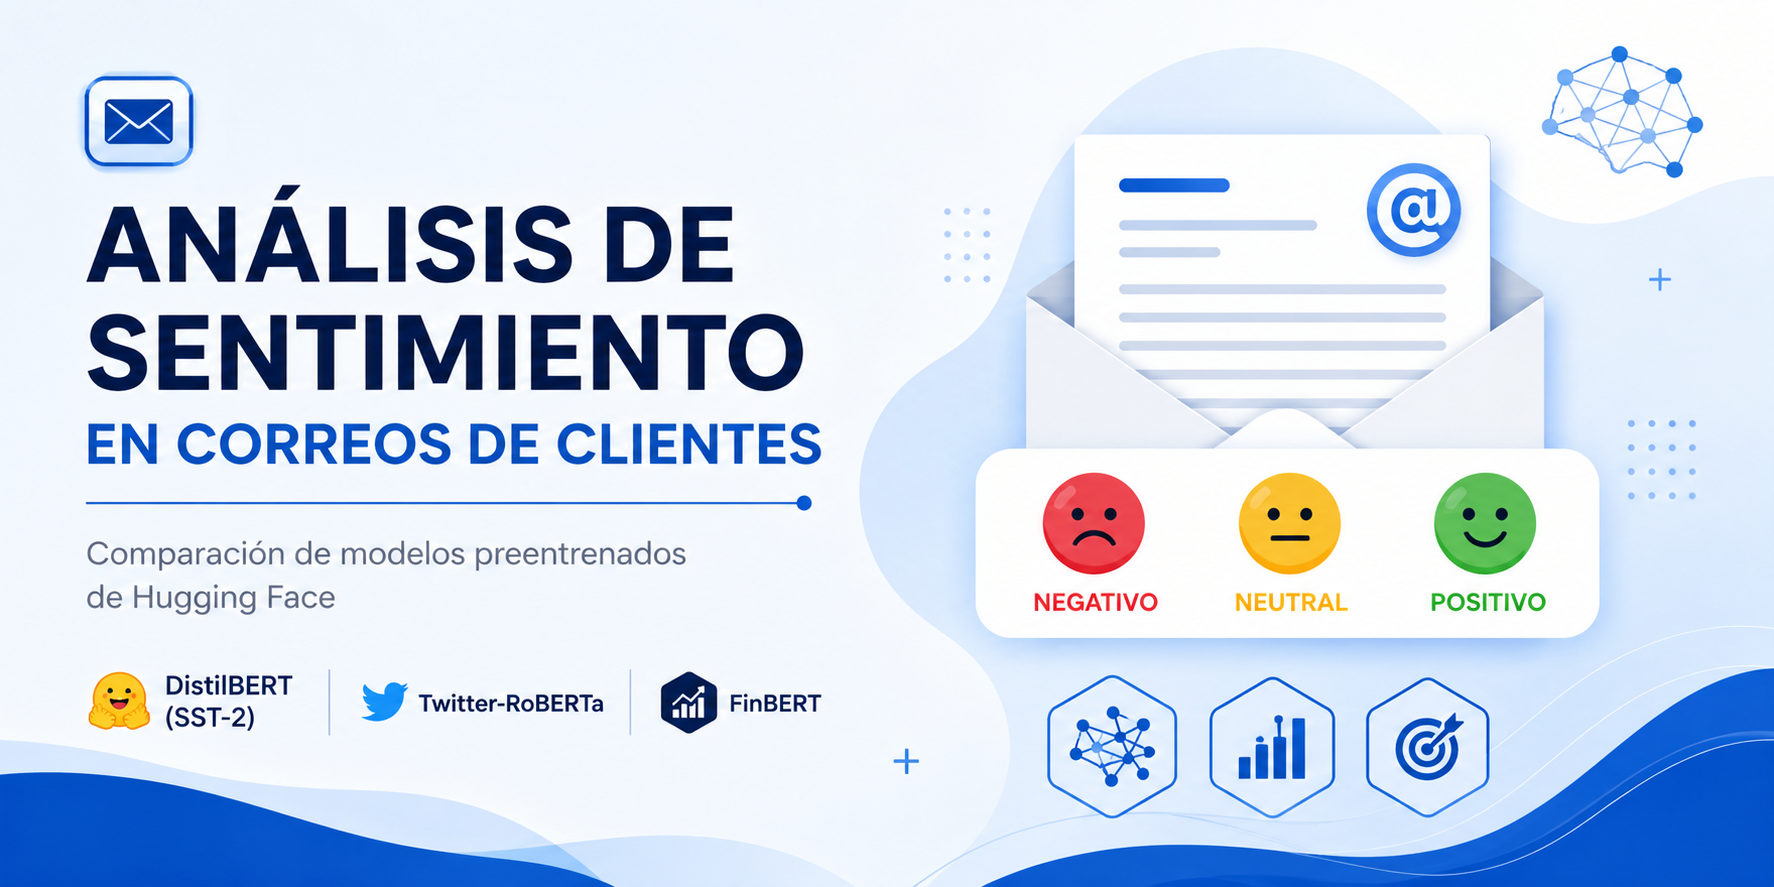

**1** **.Cuaderno Colab funcional.**

*   **Implementa al menos tres modelos con el siguiente contenido:**

*   **Configuración de GPU.**

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPU disponible" if gpus else "GPU no disponible")

*   **Instalación de dependencias.**

In [ ]:
!pip install transformers datasets evaluate

*   **Autenticación en Hugging Face Hub.**

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

*   **Carga de modelos y datasets.**

Dataset Seleccionado: Correos de clientes en inglés.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# File path:
file_path = '/content/drive/MyDrive/Inteligencia Artificial/5to Tetra: Gestión de Proyectos de IA/Modulo 2/Semana 5/Tarea/Correos_de_clientes.csv'

In [ ]:
import pandas as pd
df = pd.read_csv(file_path, sep=",", quotechar='"', engine="python")
print(df.head())

In [ ]:
print(df.shape)
print(df["sentiment"].value_counts())

In [ ]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribución de sentimientos")
plt.show()

Modelos seleccionados:
1.   distilbert/distilbert-base-uncased-finetuned-sst-2-english
2.   cardiffnlp/twitter-roberta-base-sentiment
3.   ProsusAI/finbert

In [ ]:
from transformers import pipeline

distilbert_model = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
twitter_model = "cardiffnlp/twitter-roberta-base-sentiment"
finbert_model = "ProsusAI/finbert"

In [ ]:
distilbert_classifier = pipeline("sentiment-analysis", model=distilbert_model)
twitter_classifier = pipeline("sentiment-analysis", model=twitter_model)
finbert_classifier = pipeline("sentiment-analysis", model=finbert_model)

*   **Pipeline de inferencia.**

In [ ]:
#Inferencia
distilbert_results = [distilbert_classifier(text)[0] for text in df['email']]
twitter_results = [twitter_classifier(text)[0] for text in df['email']]
finbert_results = [finbert_classifier(text)[0] for text in df['email']]

In [ ]:
# Funciones auxiliares
def assign_risk(sentiment):
    if sentiment == "negative":
        return "high"
    elif sentiment == "neutral":
        return "medium"
    else:
        return "low"

def assign_action(sentiment, risk):
    if sentiment == "negative" and risk == "high":
        return "call"
    elif sentiment == "neutral" and risk == "medium":
        return "statement"
    else:
        return "reminder"

# Ejemplo: aplicar reglas a las predicciones de DistilBERT
Distilbert_predictions = [
    "positive" if r["label"] == "POSITIVE" else "negative"
    for r in distilbert_results
]

risk_predictions = [assign_risk(s) for s in Distilbert_predictions]
action_predictions = [assign_action(s, r) for s, r in zip(Distilbert_predictions, risk_predictions)]

# Guardar en el DataFrame para análisis
df["sentiment_pred"] = Distilbert_predictions
df["risk_pred"] = risk_predictions
df["action_pred"] = action_predictions

print(df[["email", "sentiment_pred", "risk_pred", "action_pred"]].head())

In [ ]:
print(df["sentiment"].unique())

*   **Cálculo de métricas (accuracy, precision, recall, F1-score).**

In [ ]:
# MÉTRICAS

import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

# Convertir predicciones a las mismas etiquetas del dataset

# DistilBERT
Distilbert_predictions = [
    "positive" if r["label"] == "POSITIVE" else "negative"
    for r in distilbert_results
]

# Twitter-RoBERTa
Twitter_predictions = []

for r in twitter_results:
    if r["label"] == "LABEL_2":
        Twitter_predictions.append("positive")
    elif r["label"] == "LABEL_1":
        Twitter_predictions.append("neutral")
    else:
        Twitter_predictions.append("negative")

# FinBERT
Finbert_predictions = [
    r["label"].lower()
    for r in finbert_results
]

# Convertir etiquetas a números

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

y_true = [label_map[x] for x in df["sentiment"]]

y_distilbert = [label_map[x] for x in Distilbert_predictions]
y_twitter = [label_map[x] for x in Twitter_predictions]
y_finbert = [label_map[x] for x in Finbert_predictions]

# DistilBERT
accuracy_distilbert = accuracy_metric.compute(
    predictions=y_distilbert,
    references=y_true
)["accuracy"]

precision_distilbert = precision_metric.compute(
    predictions=y_distilbert,
    references=y_true,
    average="weighted"
)["precision"]

recall_distilbert = recall_metric.compute(
    predictions=y_distilbert,
    references=y_true,
    average="weighted"
)["recall"]

f1_distilbert = f1_metric.compute(
    predictions=y_distilbert,
    references=y_true,
    average="weighted"
)["f1"]

# Twitter
accuracy_twitter = accuracy_metric.compute(
    predictions=y_twitter,
    references=y_true
)["accuracy"]

precision_twitter = precision_metric.compute(
    predictions=y_twitter,
    references=y_true,
    average="weighted"
)["precision"]

recall_twitter = recall_metric.compute(
    predictions=y_twitter,
    references=y_true,
    average="weighted"
)["recall"]

f1_twitter = f1_metric.compute(
    predictions=y_twitter,
    references=y_true,
    average="weighted"
)["f1"]

# FinBERT
accuracy_finbert = accuracy_metric.compute(
    predictions=y_finbert,
    references=y_true
)["accuracy"]

precision_finbert = precision_metric.compute(
    predictions=y_finbert,
    references=y_true,
    average="weighted"
)["precision"]

recall_finbert = recall_metric.compute(
    predictions=y_finbert,
    references=y_true,
    average="weighted"
)["recall"]

f1_finbert = f1_metric.compute(
    predictions=y_finbert,
    references=y_true,
    average="weighted"
)["f1"]

print("\n=== DistilBERT ===")
print("Accuracy:", accuracy_distilbert)
print("Precision:", precision_distilbert)
print("Recall:", recall_distilbert)
print("F1:", f1_distilbert)

print("\n=== Twitter-RoBERTa ===")
print("Accuracy:", accuracy_twitter)
print("Precision:", precision_twitter)
print("Recall:", recall_twitter)
print("F1:", f1_twitter)

print("\n=== FinBERT ===")
print("Accuracy:", accuracy_finbert)
print("Precision:", precision_finbert)
print("Recall:", recall_finbert)
print("F1:", f1_finbert)

*   **Medición de latencia.**

In [ ]:
import time

start = time.time()
_ = [distilbert_classifier(text)[0] for text in df['email'][:10]]
end = time.time()
distilbert_latency = end - start

start = time.time()
_ = [twitter_classifier(text)[0] for text in df['email'][:10]]
end = time.time()
twitter_latency = end - start

start = time.time()
_ = [finbert_classifier(text)[0] for text in df['email'][:10]]
end = time.time()
finbert_latency = end - start

print("DistilBERT Latencia (10 muestras):", distilbert_latency)
print("RoBERTa Latencia (10 muestras):", twitter_latency)
print("FinBERT Latencia (10 muestras):", finbert_latency)

*   **Tablas o resúmenes.**

In [ ]:
import pandas as pd

data = {
    "Modelo": ["DistilBERT", "Twitter-RoBERTa", "FinBERT"],
    "Accuracy": [accuracy_distilbert, accuracy_twitter, accuracy_finbert],
    "Precision": [precision_distilbert, precision_twitter, precision_finbert],
    "Recall": [recall_distilbert, recall_twitter, recall_finbert],
    "F1": [f1_distilbert, f1_twitter, f1_finbert],
    "Latency": [distilbert_latency, twitter_latency, finbert_latency]
}

df_results = pd.DataFrame(data)
df_results.set_index("Modelo", inplace=True)

display(df_results.round(4))

In [ ]:
# Gráfico de barras

import matplotlib.pyplot as plt

metricas = df_results[["Accuracy", "Precision", "Recall", "F1"]]

metricas.plot(kind="bar", figsize=(10,5))

plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
#Grafica de latencia

latencia = df_results["Latency"]

latencia.plot(kind="bar", figsize=(10,5), width=0.7)

plt.title("Comparación de latencia entre modelos")
plt.ylabel("Tiempo (segundos)")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
print(label_map)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_twitter)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

disp.plot()

plt.title("Matriz de Confusión - Twitter-RoBERTa")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_distilbert)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

disp.plot()

plt.title("Matriz de Confusión - DistilBERT")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_finbert)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

disp.plot()

plt.title("Matriz de Confusión - FinBERT")
plt.show()

In [ ]:
#Ejemplo
Correo = input("Ingrese un correo electrónico: ")

# Inferencia con los tres modelos
d = distilbert_classifier(Correo)[0]
t = twitter_classifier(Correo)[0]
f = finbert_classifier(Correo)[0]

# Traducir etiquetas
distilbert_label = "positive" if d["label"] == "POSITIVE" else "negative"
twitter_map = {"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive"}
twitter_label = twitter_map[t["label"]]
finbert_label = f["label"].lower()

# Selección final (ejemplo: mayoría)
sentiments = [distilbert_label, twitter_label, finbert_label]
sentiment_final = max(set(sentiments), key=sentiments.count)

# Asignar riesgo y acción
risk_final = assign_risk(sentiment_final)
action_final = assign_action(sentiment_final, risk_final)

# Mostrar resultados
resultado = pd.DataFrame({
    "Modelo": ["DistilBERT", "Twitter-RoBERTa", "FinBERT", "Pipeline Final"],
    "Predicción": [distilbert_label, twitter_label, finbert_label, sentiment_final],
    "Confianza": [
        round(d["score"], 2),
        round(t["score"], 2),
        round(f["score"], 2),
        "-"
    ],
    "Riesgo": ["-", "-", "-", risk_final],
    "Acción": ["-", "-", "-", action_final]
})

display(resultado)

*   **Conclusiones parciales.**

* **DistilBERT:** rápido y eficiente, útil para clasificación binaria (positivo/negativo). Aunque sus métricas fueron más bajas, sus predicciones resultaron más alineadas con una lógica simple de cobranza: identificar si el cliente muestra una actitud favorable o desfavorable hacia el pago. Su principal limitación es que no contempla la categoría neutral.

* **Twitter-RoBERTa:** obtuvo las mejores métricas globales de accuracy, precision, recall y F1-score. La matriz de confusión muestra que fue el modelo más equilibrado para distinguir las tres categorías de sentimiento (negative, neutral y positive), aunque algunos correos negativos fueron clasificados como neutrales.

* **FinBERT:** especializado en lenguaje financiero. Su desempeño fue intermedio; sin embargo, tendió a concentrar la mayoría de las predicciones en la clase neutral, lo que redujo su capacidad para diferenciar adecuadamente los correos positivos y negativos de este conjunto de datos.

* El dataset presentó un ligero desbalance de clases (43 correos neutrales, 37 negativos y 19 positivos). A pesar de ello, Twitter-RoBERTa fue capaz de identificar las tres categorías de sentimiento con mayor consistencia que los demás modelos evaluados.

* En términos de desempeño, Twitter-RoBERTa fue el modelo con mejores resultados de clasificación, mientras que DistilBERT presentó la menor latencia y el tiempo de respuesta más rápido.

En conclusión, Twitter-RoBERTa resultó ser el modelo más adecuado para este conjunto de correos electrónicos debido a su capacidad para manejar las tres categorías de sentimiento. No obstante, DistilBERT puede ser una alternativa práctica cuando se requiere una clasificación rápida y binaria, mientras que FinBERT puede aportar valor en escenarios donde el contenido financiero sea más especializado.
